# Classic Practical Cases for Rates CTA

This notebook uses offline synthetic interest-rate data to demonstrate a practical rates CTA research framework from a bank S&T perspective. The goal is not to prove that any specific strategy makes money, but to make the core concepts concrete: duration PnL, trend-following, volatility targeting, curve CTA, carry/roll-down, portfolio risk, and stress testing.

In a real project, you can replace `simulate_yield_curves()` with Bloomberg, Refinitiv, FRED, or internal curve data.

## 0. Imports and Global Settings

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

TRADING_DAYS = 252
RNG = np.random.default_rng(42)

## 1. Generate an Interpretable Multi-Market Rates Curve Dataset

To keep the notebook independent of external data, this section simulates 2Y/5Y/10Y/30Y curves for USD, EUR, GBP, JPY, and AUD using three intuitive factors: level, slope, and curvature.

Unit convention: yields are decimals. For example, `0.035` means 3.5%.

In [3]:
markets = ["USD", "EUR", "GBP", "JPY", "AUD"]
tenors = np.array([2.0, 5.0, 10.0, 30.0])
duration_map = pd.Series({2.0: 1.9, 5.0: 4.6, 10.0: 8.5, 30.0: 18.0})

def simulate_yield_curves(start="2014-01-02", end="2025-12-31", seed=7):
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start, end)
    n = len(dates)

    start_level = {"USD": 0.025, "EUR": 0.010, "GBP": 0.023, "JPY": 0.002, "AUD": 0.030}
    start_slope = {"USD": 0.010, "EUR": 0.008, "GBP": 0.007, "JPY": 0.004, "AUD": 0.006}
    phase = {"USD": 0.2, "EUR": 1.3, "GBP": 0.7, "JPY": 2.0, "AUD": 2.7}

    slope_loading = pd.Series({2.0: -0.55, 5.0: -0.15, 10.0: 0.10, 30.0: 0.45})
    curve_loading = pd.Series({2.0: -0.25, 5.0: 0.35, 10.0: 0.20, 30.0: -0.30})

    common_level = rng.normal(0, 3.0, n).cumsum() / 10000
    common_slope = rng.normal(0, 1.4, n).cumsum() / 10000
    common_curve = rng.normal(0, 0.9, n).cumsum() / 10000

    all_curves = {}
    t = np.linspace(0, 5 * np.pi, n)
    for m in markets:
        local_level = rng.normal(0, 2.0, n).cumsum() / 10000
        local_slope = rng.normal(0, 1.1, n).cumsum() / 10000
        local_curve = rng.normal(0, 0.8, n).cumsum() / 10000

        cycle = 0.009 * np.sin(t + phase[m])
        level = start_level[m] + cycle + 0.65 * common_level + 0.70 * local_level
        slope = start_slope[m] + 0.60 * common_slope + 0.85 * local_slope
        curvature = 0.002 * np.sin(0.7 * t + phase[m]) + 0.50 * common_curve + 0.80 * local_curve

        for tenor in tenors:
            y = level + slope * slope_loading.loc[tenor] + curvature * curve_loading.loc[tenor]
            y = np.clip(y, -0.010, 0.085)
            all_curves[(m, tenor)] = y

    columns = pd.MultiIndex.from_tuples(all_curves.keys(), names=["market", "tenor"])
    return pd.DataFrame(all_curves, index=dates, columns=columns)

yields = simulate_yield_curves()
yields.tail()

market         USD                             EUR                          \
tenor      2.0000  5.0000  10.0000 30.0000 2.0000  5.0000  10.0000 30.0000   
2025-12-25  0.0045  0.0062  0.0110  0.0198 -0.0100 -0.0100 -0.0100 -0.0100   
2025-12-26  0.0047  0.0062  0.0110  0.0198 -0.0100 -0.0100 -0.0100 -0.0100   
2025-12-29  0.0047  0.0063  0.0111  0.0198 -0.0100 -0.0100 -0.0100 -0.0100   
2025-12-30  0.0046  0.0062  0.0110  0.0198 -0.0100 -0.0100 -0.0100 -0.0100   
2025-12-31  0.0045  0.0061  0.0110  0.0199 -0.0100 -0.0100 -0.0100 -0.0100   

market         GBP                             JPY                          \
tenor      2.0000  5.0000  10.0000 30.0000 2.0000  5.0000  10.0000 30.0000   
2025-12-25 -0.0030 -0.0079 -0.0071 -0.0037 -0.0100 -0.0100 -0.0100 -0.0100   
2025-12-26 -0.0028 -0.0077 -0.0069 -0.0035 -0.0100 -0.0100 -0.0100 -0.0100   
2025-12-29 -0.0031 -0.0079 -0.0070 -0.0036 -0.0100 -0.0100 -0.0100 -0.0100   
2025-12-30 -0.0031 -0.0081 -0.0072 -0.0038 -0.0100 -0.0100 -0.0100 -0.0100   
2025-12-31 -0.0032 -0.0081 -0.0072 -0.0039 -0.0100 -0.0100 -0.0100 -0.0100   

market         AUD                          
tenor      2.0000  5.0000  10.0000 30.0000  
2025-12-25  0.0107  0.0142  0.0174  0.0224  
2025-12-26  0.0107  0.0142  0.0174  0.0226  
2025-12-29  0.0107  0.0142  0.0174  0.0225  
2025-12-30  0.0108  0.0144  0.0176  0.0226  
2025-12-31  0.0106  0.0143  0.0176  0.0226

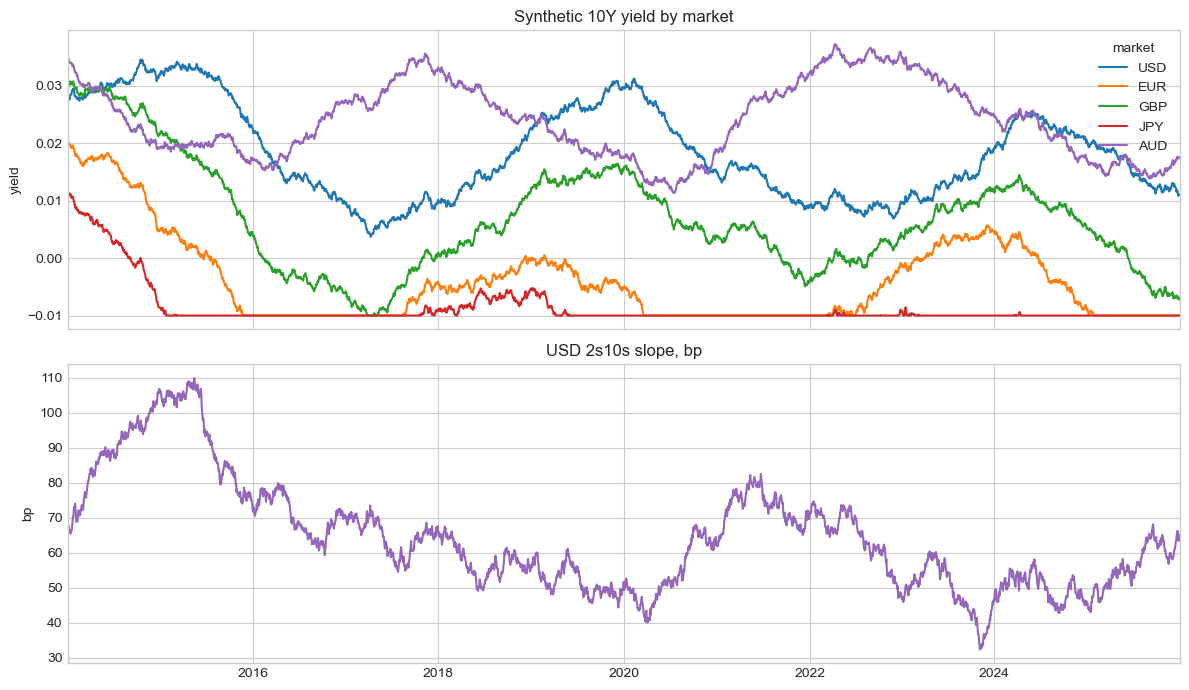

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
yields.xs(10.0, level="tenor", axis=1).plot(ax=axes[0], title="Synthetic 10Y yield by market")
(10000 * (yields[("USD", 10.0)] - yields[("USD", 2.0)])).plot(ax=axes[1], title="USD 2s10s slope, bp", color="tab:purple")
axes[0].set_ylabel("yield")
axes[1].set_ylabel("bp")
plt.tight_layout()

## 2. Convert Yields into a Duration Return Proxy

This section uses the simplest approximation:

`long duration return ≈ -duration × yield_change + yield / 252`

Real government bond futures require CTD, conversion factors, roll treatment, implied repo, and delivery options. Real swaps require PV01, curve bumps, and discounting. Here we keep the intuition simple.

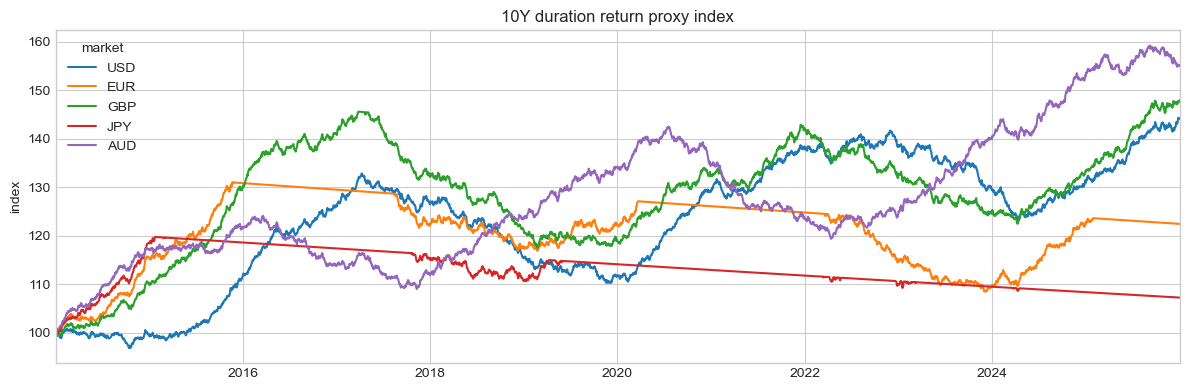

In [5]:
def make_duration_return_proxy(yield_curves, duration_map):
    pieces = {}
    for market, tenor in yield_curves.columns:
        dy = yield_curves[(market, tenor)].diff()
        carry = yield_curves[(market, tenor)].shift(1) / TRADING_DAYS
        ret = -duration_map.loc[tenor] * dy + carry
        pieces[(market, tenor)] = ret
    columns = pd.MultiIndex.from_tuples(pieces.keys(), names=["market", "tenor"])
    return pd.DataFrame(pieces, index=yield_curves.index, columns=columns).dropna()

rates_returns = make_duration_return_proxy(yields, duration_map)
proxy_prices = 100 * (1 + rates_returns).cumprod()

proxy_prices.xs(10.0, level="tenor", axis=1).plot(figsize=(12, 4), title="10Y duration return proxy index")
plt.ylabel("index")
plt.tight_layout()

## 3. Backtesting Helper Functions

These functions are reused across the cases below: performance metrics, drawdown, volatility targeting, transaction costs, and signal lag. Positions use `shift(1)` to avoid using a same-day close signal to trade the same-day return.

In [6]:
def max_drawdown(pnl):
    equity = (1 + pnl.fillna(0)).cumprod()
    return (equity / equity.cummax() - 1).min()

def performance_table(pnl, name="strategy"):
    if isinstance(pnl, pd.DataFrame):
        return pd.DataFrame({col: performance_table(pnl[col], str(col)).iloc[:, 0] for col in pnl.columns})
    pnl = pnl.dropna()
    ann_ret = pnl.mean() * TRADING_DAYS
    ann_vol = pnl.std() * np.sqrt(TRADING_DAYS)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    hit_rate = (pnl > 0).mean()
    out = pd.Series({
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown(pnl),
        "hit_rate": hit_rate,
    }, name=name)
    return out.to_frame()

def trend_following_backtest(returns, lookback=63, vol_span=63, target_vol=0.10, cost_bps=0.5, max_leverage=4.0):
    trend = returns.rolling(lookback).sum()
    signal = np.sign(trend)
    realized_vol = returns.ewm(span=vol_span, min_periods=vol_span).std() * np.sqrt(TRADING_DAYS)
    gross_position = signal * (target_vol / realized_vol)
    position = gross_position.clip(lower=-max_leverage, upper=max_leverage).fillna(0)

    gross_pnl = position.shift(1) * returns
    turnover = position.diff().abs().fillna(0)
    costs = turnover * cost_bps / 10000
    net_pnl = gross_pnl - costs
    return net_pnl.dropna(), position, signal, costs

def plot_equity(pnl, title):
    equity = (1 + pnl.fillna(0)).cumprod()
    ax = equity.plot(figsize=(12, 4), title=title)
    ax.set_ylabel("growth of $1")
    plt.tight_layout()
    return ax

## Case 1: Classic 10Y Rates Trend-Following

This is the closest version to traditional CTA: for each market, look at the past 3-month trend of the 10Y duration proxy. Positive trend goes long, negative trend goes short, and the position is then volatility-targeted.

,ann_return,ann_vol,sharpe,max_drawdown,hit_rate
USD,0.1604,0.1017,1.5768,-0.2327,0.5275
EUR,0.1266,0.0809,1.5646,-0.2091,0.6605
GBP,0.1937,0.1016,1.9064,-0.1810,0.5438
JPY,0.0667,0.0518,1.2881,-0.1371,0.8242
AUD,0.1670,0.1010,1.6528,-0.1647,0.5432


,10Y trend portfolio
ann_return,0.1429
ann_vol,0.0503
sharpe,2.8411
max_drawdown,-0.0668
hit_rate,0.5748


<Axes: title={'center': 'Case 1: 10Y rates trend-following portfolio'}, ylabel='growth of $1'>

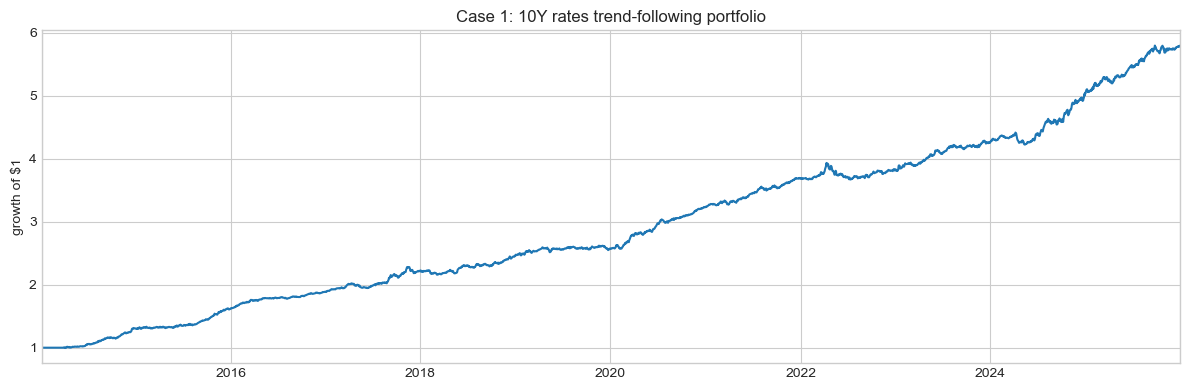

In [7]:
ten_y_returns = rates_returns.xs(10.0, level="tenor", axis=1)
tf_pnl_by_market, tf_position, tf_signal, tf_costs = trend_following_backtest(
    ten_y_returns, lookback=63, vol_span=63, target_vol=0.10, cost_bps=0.5, max_leverage=4.0
)
tf_portfolio = tf_pnl_by_market.mean(axis=1)

display(performance_table(tf_pnl_by_market).T)
display(performance_table(tf_portfolio, "10Y trend portfolio"))
plot_equity(tf_portfolio, "Case 1: 10Y rates trend-following portfolio")

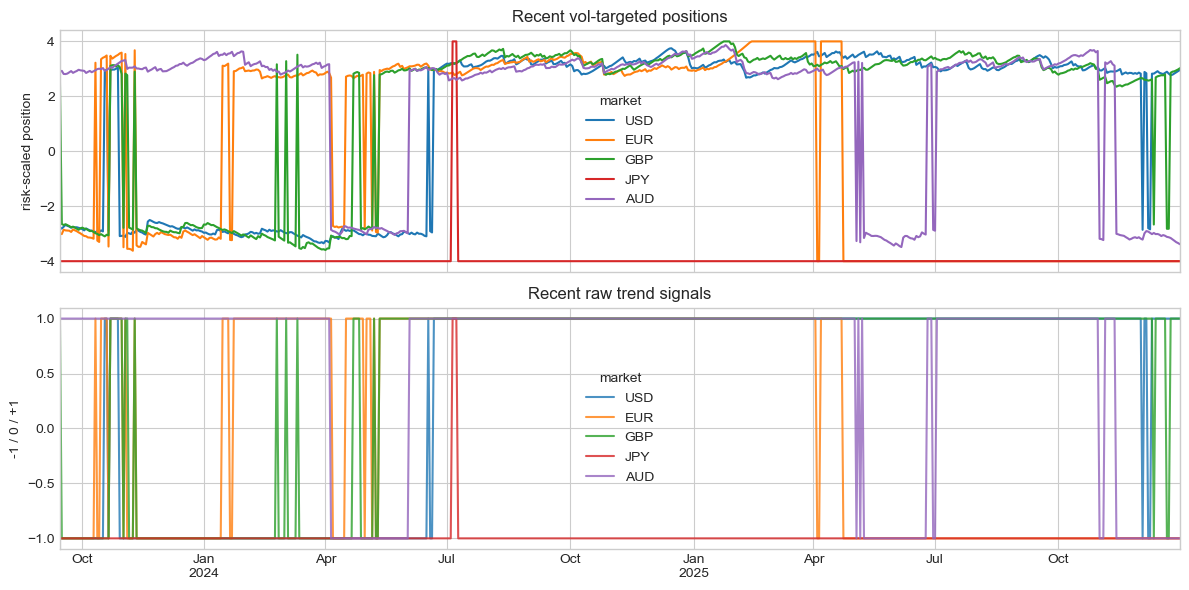

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
tf_position.tail(600).plot(ax=axes[0], title="Recent vol-targeted positions")
tf_signal.tail(600).plot(ax=axes[1], title="Recent raw trend signals", alpha=0.8)
axes[0].set_ylabel("risk-scaled position")
axes[1].set_ylabel("-1 / 0 / +1")
plt.tight_layout()

Things to observe:

- The sign of a rates CTA position should align with yield intuition: long duration means betting on lower yields.
- Volatility targeting automatically reduces exposure during high-volatility periods.
- Faster parameters are not always better. Fast signals react quickly, but they are also more exposed to whipsaw.

## Case 2: Robustness Across Different Lookbacks

In a bank research project, you should not only show the best-performing parameter. Below we compare 1M, 3M, 6M, and 12M trend signals.

,ann_return,ann_vol,sharpe,max_drawdown,hit_rate
1M,0.1083,0.0531,2.0375,-0.0976,0.5540
3M,0.1429,0.0503,2.8411,-0.0668,0.5748
6M,0.1521,0.0479,3.1764,-0.0625,0.5697
12M,0.1182,0.0448,2.6364,-0.0410,0.5262


<Axes: title={'center': 'Case 2: lookback comparison'}, ylabel='growth of $1'>

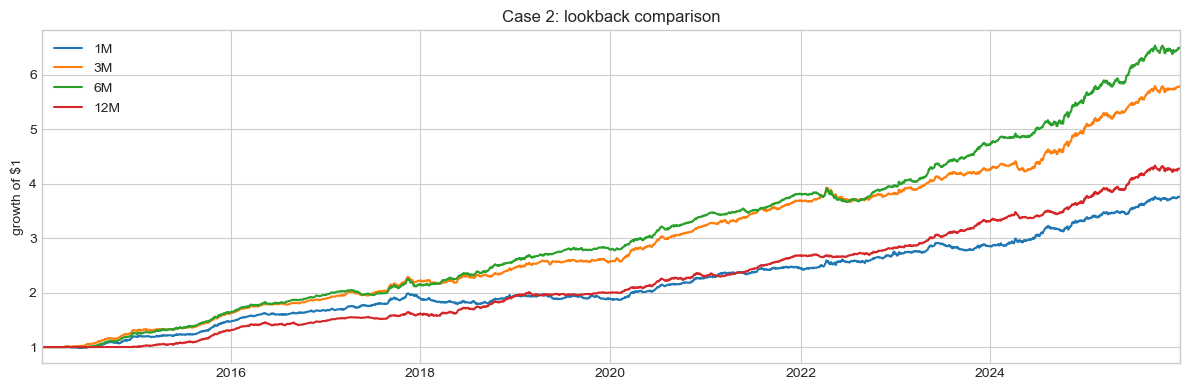

In [9]:
lookbacks = {"1M": 21, "3M": 63, "6M": 126, "12M": 252}
lb_results = {}
lb_pnls = {}

for label, lb in lookbacks.items():
    pnl_by_market, _, _, _ = trend_following_backtest(ten_y_returns, lookback=lb, target_vol=0.10, cost_bps=0.5)
    port = pnl_by_market.mean(axis=1)
    lb_pnls[label] = port
    lb_results[label] = performance_table(port, label).iloc[:, 0]

lb_summary = pd.DataFrame(lb_results).T
display(lb_summary)
plot_equity(pd.DataFrame(lb_pnls), "Case 2: lookback comparison")

Research habit: if only one parameter works while the others fail, be careful. Real CTA programs often blend multiple lookbacks and care more about parameter stability than single-point optimization.

## Case 3: 2s10s Curve CTA

This is an educational curve CTA example: if the 2s10s slope steepened over the past 3 months, enter a steepener; if it flattened, enter a flattener.

Real trades must be DV01-neutral. Here, slope change is used as a simplified proxy for DV01-neutral curve PnL: a steepener makes money when the slope rises, while a flattener makes money when the slope falls.

,ann_return,ann_vol,sharpe,max_drawdown,hit_rate
USD,-0.0009,0.0069,-0.1256,-0.0338,0.4834
EUR,0.0049,0.0080,0.6150,-0.0190,0.2996
GBP,-0.0024,0.0072,-0.3318,-0.0541,0.4856
JPY,-0.0017,0.0062,-0.2767,-0.0372,0.1039
AUD,-0.0019,0.0072,-0.2622,-0.0522,0.4866


,2s10s curve trend portfolio
ann_return,-0.0004
ann_vol,0.0036
sharpe,-0.1097
max_drawdown,-0.0257
hit_rate,0.4789


<Axes: title={'center': 'Case 3: 2s10s curve trend-following'}, ylabel='growth of $1'>

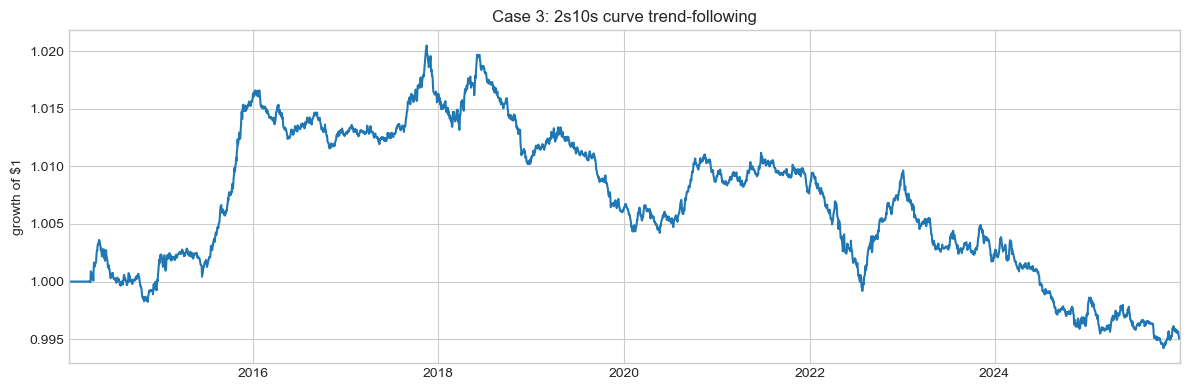

In [10]:
def curve_trend_backtest(yield_curves, short_tenor=2.0, long_tenor=10.0, lookback=63, target_vol=0.08, cost_bp=0.10):
    slopes = pd.DataFrame({m: yield_curves[(m, long_tenor)] - yield_curves[(m, short_tenor)] for m in markets})
    curve_return = slopes.diff().dropna()
    signal = np.sign(slopes.diff(lookback)).reindex(curve_return.index).fillna(0)
    vol = curve_return.ewm(span=63, min_periods=63).std() * np.sqrt(TRADING_DAYS)
    position = (signal * (target_vol / vol)).clip(-5, 5).fillna(0)
    gross = position.shift(1) * curve_return
    cost = position.diff().abs().fillna(0) * cost_bp / 10000
    net = gross - cost
    return net.dropna(), position, signal, slopes

curve_pnl_by_market, curve_position, curve_signal, slopes = curve_trend_backtest(yields)
curve_portfolio = curve_pnl_by_market.mean(axis=1)

display(performance_table(curve_pnl_by_market).T)
display(performance_table(curve_portfolio, "2s10s curve trend portfolio"))
plot_equity(curve_portfolio, "Case 3: 2s10s curve trend-following")

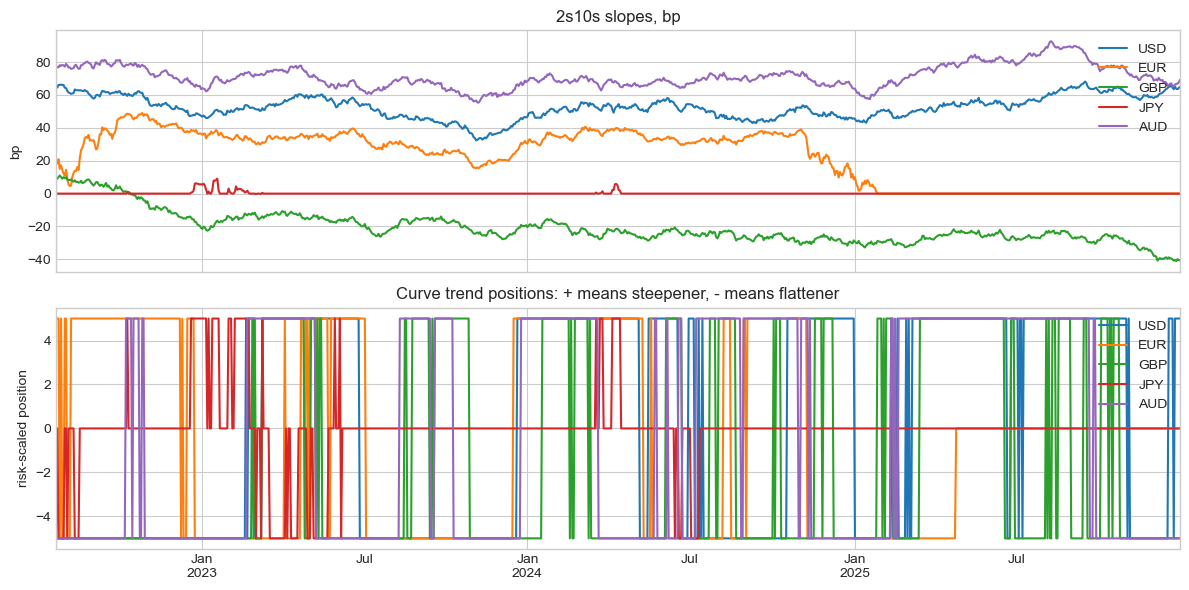

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
(10000 * slopes.tail(900)).plot(ax=axes[0], title="2s10s slopes, bp")
curve_position.tail(900).plot(ax=axes[1], title="Curve trend positions: + means steepener, - means flattener")
axes[0].set_ylabel("bp")
axes[1].set_ylabel("risk-scaled position")
plt.tight_layout()

Interview points for curve CTA:

- Be clear about the direction of steepeners and flatteners.
- Use DV01-neutral language to show that you are not accidentally trading duration.
- Curve strategies have different costs, liquidity, and return distributions from outright duration trades.

## Case 4: Carry and Roll-Down Cross-Sectional Strategy

Carry/roll-down is a very important rates risk premium. In simple terms, when the curve is upward sloping, a long-duration position may roll toward a lower-yield point as maturity shortens, producing roll-down return.

Below we use a simplified formula:

`roll_score ≈ duration × (current_yield - yield_at_tenor_minus_horizon)`

The higher the score, the more the strategy leans long. The lower the score, the more it leans short.

In [12]:
def compute_roll_down_scores(yield_curves, horizon_years=0.25):
    scores = {}
    for m in markets:
        curve = yield_curves[m]
        for tenor in tenors:
            target_tenor = max(float(tenors.min()), tenor - horizon_years)
            rolled_yield = curve.apply(lambda row: np.interp(target_tenor, tenors, row.values), axis=1)
            current_yield = curve[tenor]
            scores[(m, tenor)] = duration_map.loc[tenor] * (current_yield - rolled_yield)
    columns = pd.MultiIndex.from_tuples(scores.keys(), names=["market", "tenor"])
    return pd.DataFrame(scores, index=yield_curves.index, columns=columns)

roll_scores = compute_roll_down_scores(yields)
latest_scores = (10000 * roll_scores.iloc[-1]).sort_values(ascending=False).to_frame("roll_score_bp_equiv")
latest_scores.head(10)

roll_score_bp_equiv
market tenor                       
USD    10.0000              20.7548
       30.0000              20.1975
AUD    5.0000               14.1767
       10.0000              13.7167
       30.0000              11.3050
GBP    30.0000               7.6379
USD    5.0000                6.1927
GBP    10.0000               3.7000
       2.0000                0.0000
EUR    30.0000               0.0000

,carry / roll-down cross-section
ann_return,0.0590
ann_vol,0.0600
sharpe,0.9830
max_drawdown,-0.2361
hit_rate,0.5149


<Axes: title={'center': 'Case 4: carry / roll-down cross-sectional strategy'}, ylabel='growth of $1'>

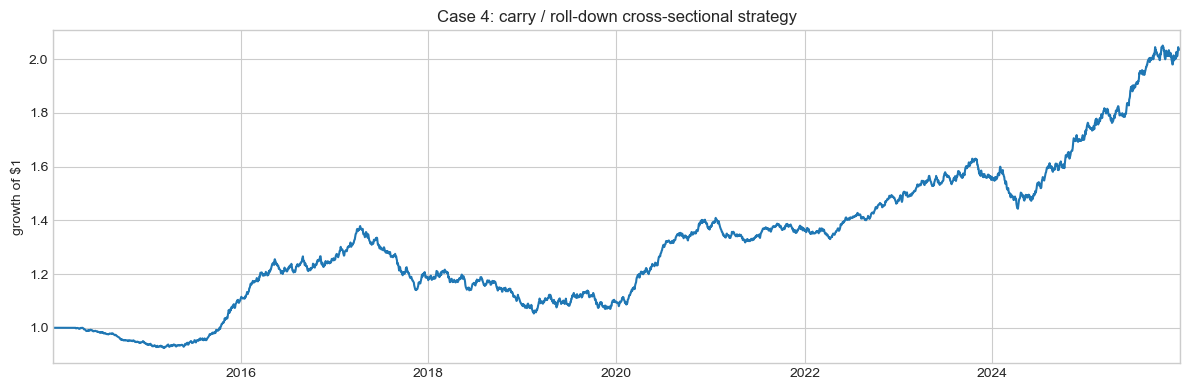

In [13]:
def cross_sectional_carry_backtest(returns, roll_scores, target_vol=0.08, cost_bps=0.5):
    aligned_scores = roll_scores.reindex(returns.index).shift(1)
    demeaned = aligned_scores.sub(aligned_scores.mean(axis=1), axis=0)
    score_vol = demeaned.std(axis=1).replace(0, np.nan)
    raw_weight = demeaned.div(score_vol, axis=0).clip(-2, 2).fillna(0)
    raw_weight = raw_weight.div(raw_weight.abs().sum(axis=1), axis=0).fillna(0)

    raw_pnl = (raw_weight.shift(1) * returns).sum(axis=1)
    realized_vol = raw_pnl.ewm(span=63, min_periods=63).std() * np.sqrt(TRADING_DAYS)
    scale = (target_vol / realized_vol).clip(upper=4).fillna(0)
    weight = raw_weight.mul(scale, axis=0)

    gross = (weight.shift(1) * returns).sum(axis=1)
    turnover = weight.diff().abs().sum(axis=1).fillna(0)
    cost = turnover * cost_bps / 10000
    net = gross - cost
    return net.dropna(), weight

carry_pnl, carry_weights = cross_sectional_carry_backtest(rates_returns, roll_scores)
display(performance_table(carry_pnl, "carry / roll-down cross-section"))
plot_equity(carry_pnl, "Case 4: carry / roll-down cross-sectional strategy")

In [14]:
top_latest_weights = carry_weights.iloc[-1].sort_values(ascending=False).to_frame("latest_weight")
display(top_latest_weights.head(8))
display(top_latest_weights.tail(8))

latest_weight
market tenor                 
USD    10.0000         0.5251
       30.0000         0.5069
AUD    5.0000          0.3114
       10.0000         0.3086
       30.0000         0.2351
GBP    30.0000         0.1198
USD    5.0000          0.0745
GBP    10.0000        -0.0056

latest_weight
market tenor                 
JPY    5.0000         -0.1230
       10.0000        -0.1230
       30.0000        -0.1230
AUD    2.0000         -0.1230
EUR    5.0000         -0.1230
       2.0000         -0.1230
USD    2.0000         -0.1230
GBP    5.0000         -0.5598

Real-world complexity in carry/roll-down:

- Government bond futures carry depends on CTD, repo, and delivery options.
- Swaps require the forward curve, discounting, collateral assumptions, and day count conventions.
- High carry may be compensation for risk, not a free lunch. It can lose money quickly during trend reversals or central-bank repricing.

## Case 5: Combined CTA Portfolio and Stress Report

Finally, combine three sleeves: 10Y trend, 2s10s curve trend, and carry/roll-down. A real project would add more constraints, such as market caps, DV01 caps, leverage caps, and correlation caps.

,ann_return,ann_vol,sharpe,max_drawdown,hit_rate
10Y_trend,0.1429,0.0503,2.8411,-0.0668,0.5748
2s10s_curve_trend,-0.0004,0.0036,-0.1097,-0.0257,0.4789
carry_roll_down,0.0590,0.0600,0.9832,-0.2361,0.5150


,combined rates CTA
ann_return,0.0113
ann_vol,0.0059
sharpe,1.9245
max_drawdown,-0.0096
hit_rate,0.5342


<Axes: title={'center': 'Case 5: strategy sleeves and combined portfolio'}, ylabel='growth of $1'>

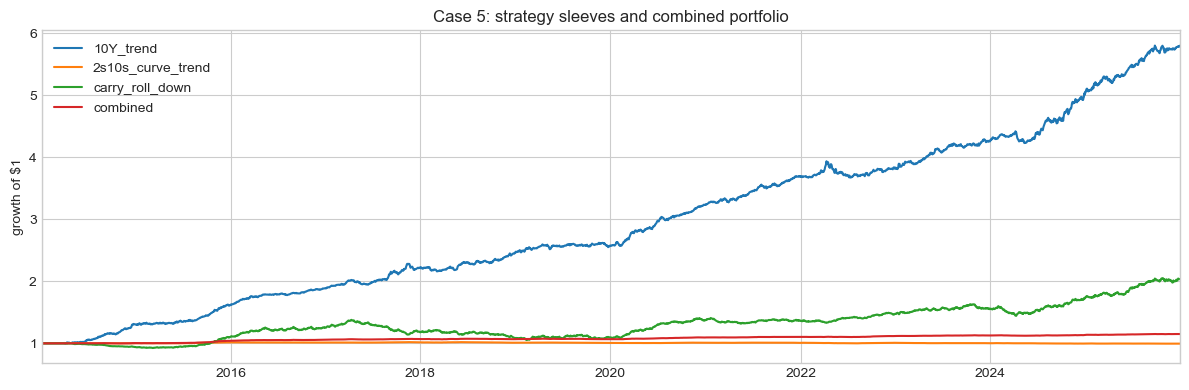

In [15]:
strategy_pnls = pd.concat({
    "10Y_trend": tf_portfolio,
    "2s10s_curve_trend": curve_portfolio,
    "carry_roll_down": carry_pnl,
}, axis=1).dropna()

def inverse_vol_weights(pnls, span=126):
    vol = pnls.ewm(span=span, min_periods=span).std() * np.sqrt(TRADING_DAYS)
    inv = 1 / vol.replace(0, np.nan)
    weights = inv.div(inv.sum(axis=1), axis=0).fillna(0)
    return weights

sleeve_weights = inverse_vol_weights(strategy_pnls)
combined_pnl = (sleeve_weights.shift(1) * strategy_pnls).sum(axis=1).dropna()

display(performance_table(strategy_pnls).T)
display(performance_table(combined_pnl, "combined rates CTA"))
plot_equity(pd.concat([strategy_pnls, combined_pnl.rename("combined")], axis=1), "Case 5: strategy sleeves and combined portfolio")

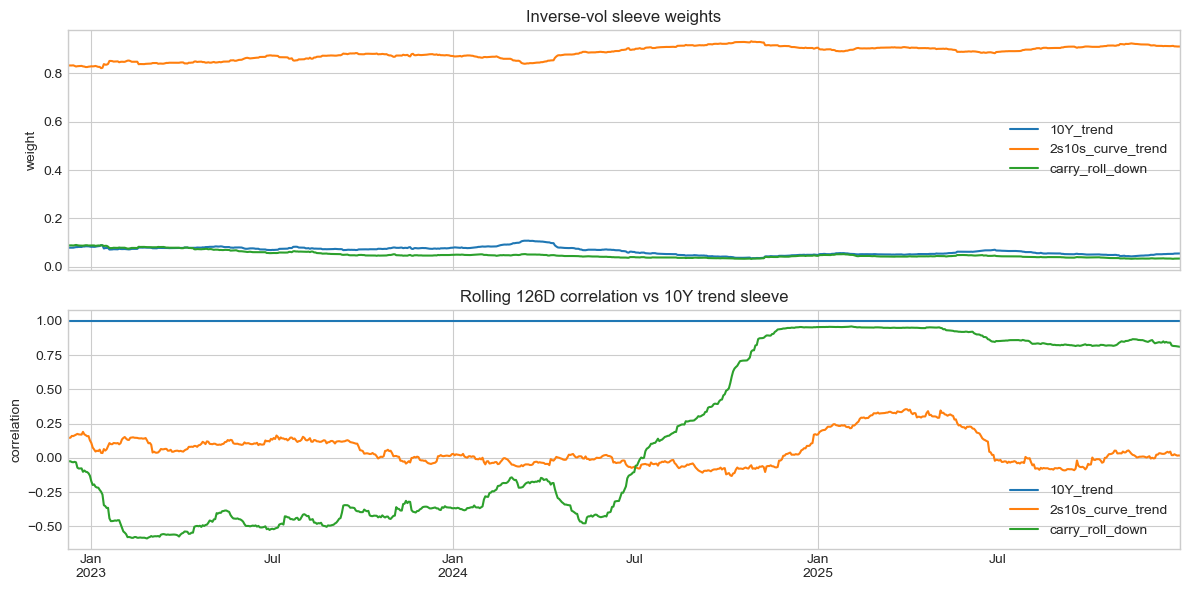

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sleeve_weights.tail(800).plot(ax=axes[0], title="Inverse-vol sleeve weights")
(strategy_pnls.rolling(126).corr().xs("10Y_trend", level=1).tail(800)).plot(ax=axes[1], title="Rolling 126D correlation vs 10Y trend sleeve")
axes[0].set_ylabel("weight")
axes[1].set_ylabel("correlation")
plt.tight_layout()

Below is a very simplified stress report. It answers the question: if all 10Y yields rise by 100bp tomorrow, what might happen to the current 10Y trend sleeve?

A real desk stress report would decompose risk by DV01, tenor bucket, curve shock, basis shock, volatility shock, and liquidity shock.

In [17]:
def simple_10y_parallel_stress(position, shock_bp=100):
    latest_pos = position.iloc[-1]
    dy = shock_bp / 10000
    shock_return_per_1x = -duration_map.loc[10.0] * dy
    pnl = latest_pos * shock_return_per_1x
    return pnl.sort_values().to_frame(f"pnl_if_10y_yield_up_{shock_bp}bp")

stress_100bp = simple_10y_parallel_stress(tf_position, shock_bp=100)
display(stress_100bp)
print("Portfolio stress approximation:", f"{stress_100bp.mean().iloc[0]:.2%}")

,pnl_if_10y_yield_up_100bp
market,
GBP,-0.2572
USD,-0.2518
AUD,0.2877
EUR,0.3400
JPY,0.3400


Portfolio stress approximation: 9.17%


## 6. How to Turn This Notebook into a Real Bank S&T Project

Suggested roadmap:

1. Replace the data: use futures settlement prices, swap curves, or internal risk-system outputs instead of synthetic data.
2. Be explicit about units: standardize every strategy to returns, DV01 PnL, or target volatility. Do not mix them casually.
3. Build continuous contracts: handle futures rolls to avoid artificial jumps.
4. Add realistic costs: bid/ask, roll costs, slippage, and swap execution costs.
5. Test parameter stability: lookback, volatility span, costs, market universe, and start date.
6. Produce explainable outputs: signals, positions, turnover, drawdown, market contribution, and stress.
7. Build the S&T version: daily monitor + client talking points + signal flip levels.

If you are asked in an interview, “How would you build a rates CTA project?”, you can start with this framework and then shift the emphasis depending on whether the audience is trading, sales, research, or structuring.